In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
def get_palette(list_of_colors: list):
    palette= {'Black/Dark gray': "#0a0a0a",  'Blue':"#0a62fa", 'Green':"#1aaf00",  'Light gray/Silver':"#c8c8c8", 'Orange':"#f77e0d",'Red':"#fa0a0a",'White':"#f5f5f5", 'Yellow':"#ffe600"}
    return [palette[i] for i in list_of_colors]

lighting_palette = palette=["#FFE368", "#8B8462", "#282828"]

In [22]:
internal = pd.read_csv('../annotations/internal.csv')
external = pd.read_csv("../annotations/external.csv")

annotations = {
    "Intern": {
        "cars": internal,
        "filtered": {
            "Model S": internal[internal['model'] == 'S'],
            "Model X": internal[internal['model'] == 'X'],
            "Model 3": internal[internal['model'] == '3'],
            "Model Y": internal[internal['model'] == 'Y'],
        }
    },
    "Ekstern": {
        "cars": external,
        "filtered": {
            "Model S": external[external['model'] == 'S'],
            "Model X": external[external['model'] == 'X'],
            "Model 3": external[external['model'] == '3'],
            "Model Y": external[external['model'] == 'Y'],
        }
    },
    "Alle": {
        "cars": pd.concat([internal, external], ignore_index=True),
        "filtered": {
            "Model S": pd.concat([internal[internal['model'] == 'S'], external[external['model'] == 'S']], ignore_index=True),
            "Model X": pd.concat([internal[internal['model'] == 'X'], external[external['model'] == 'X']], ignore_index=True),
            "Model 3": pd.concat([internal[internal['model'] == '3'], external[external['model'] == '3']], ignore_index=True),
            "Model Y": pd.concat([internal[internal['model'] == 'Y'], external[external['model'] == 'Y']], ignore_index=True),
        }
    }
}

other = 'Other car'

sns.set_theme(style="darkgrid", font_scale=0.9)

C:\Users\johan\AppData\Local\Temp\ipykernel_26568\2200401239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=data, palette=["#fa0a0a", "#6f6f6f"])


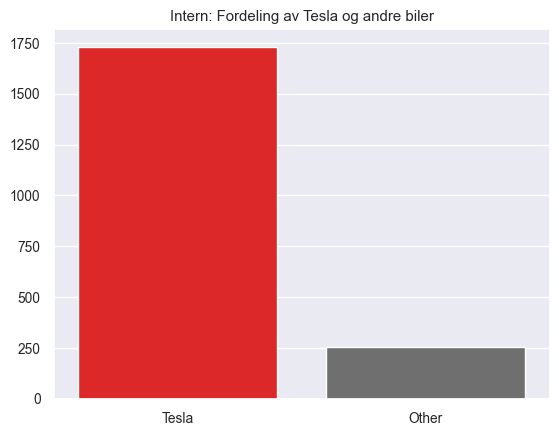

C:\Users\johan\AppData\Local\Temp\ipykernel_26568\2200401239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=data, palette=["#fa0a0a", "#6f6f6f"])


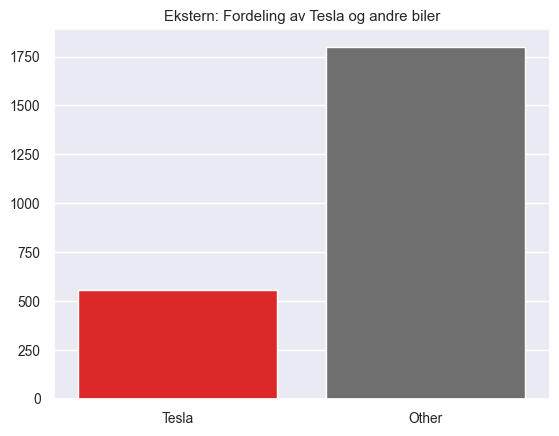

C:\Users\johan\AppData\Local\Temp\ipykernel_26568\2200401239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=data, palette=["#fa0a0a", "#6f6f6f"])


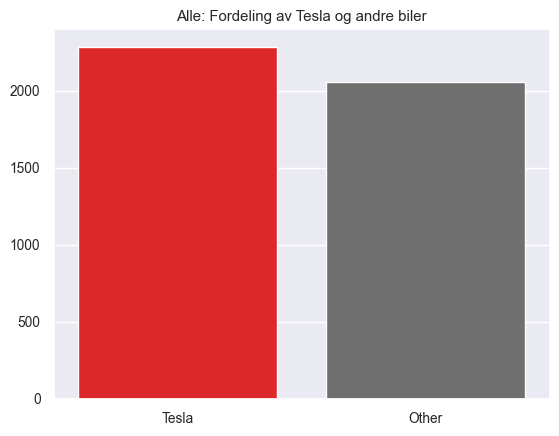

In [23]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    data={'Tesla': len(df[df['model'] != other]), 'Other': len(df[df['model'] == other])}
    plot = sns.barplot(data=data, palette=["#fa0a0a", "#6f6f6f"])
    plot.set_title(f'{annotation_name}: Fordeling av Tesla og andre biler')
    plt.show()

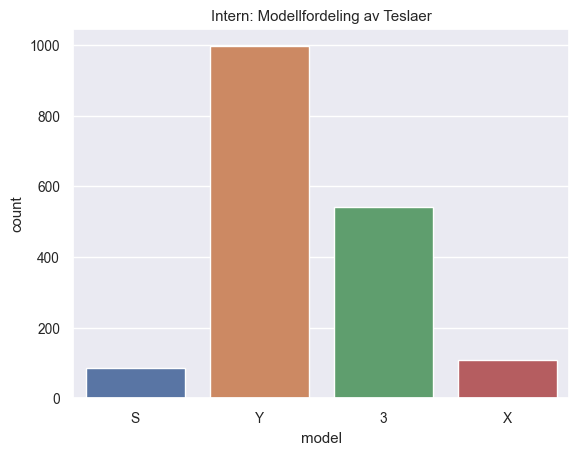

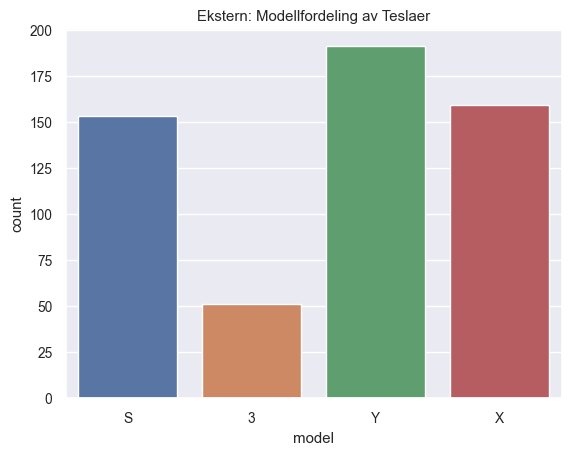

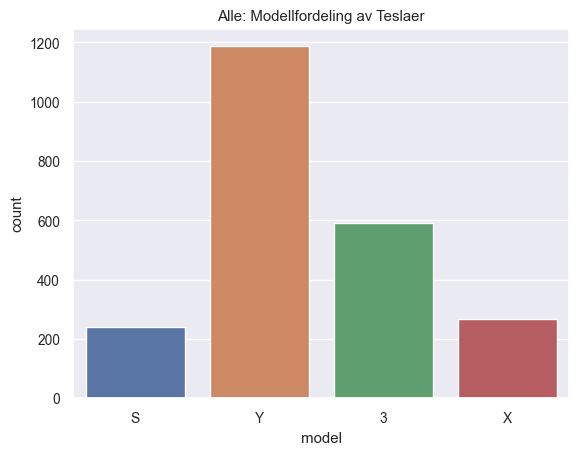

In [24]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    data = df[df['model'] != other]
    plot = sns.countplot(data=data, x='model', hue='model')
    plot.set_title(f'{annotation_name}: Modellfordeling av Teslaer')
    plt.show()

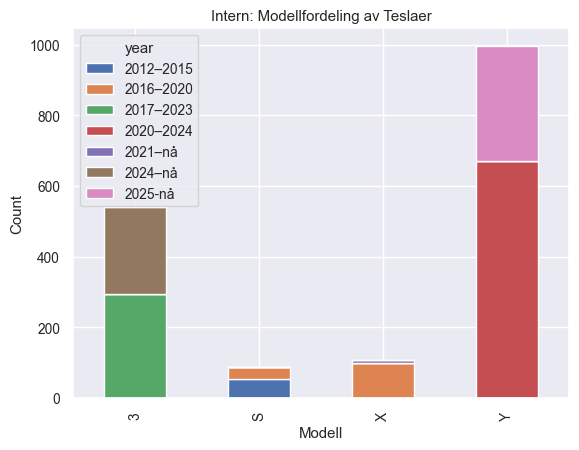

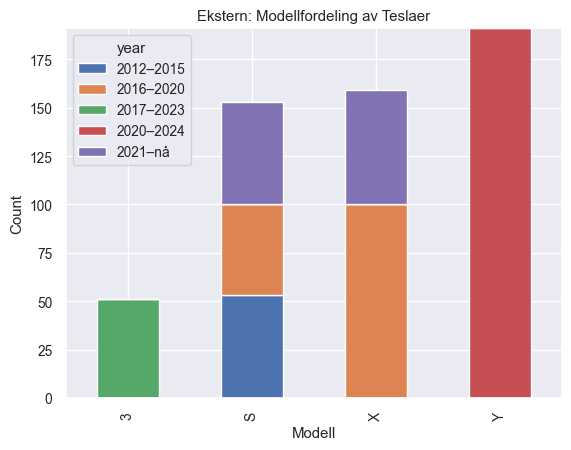

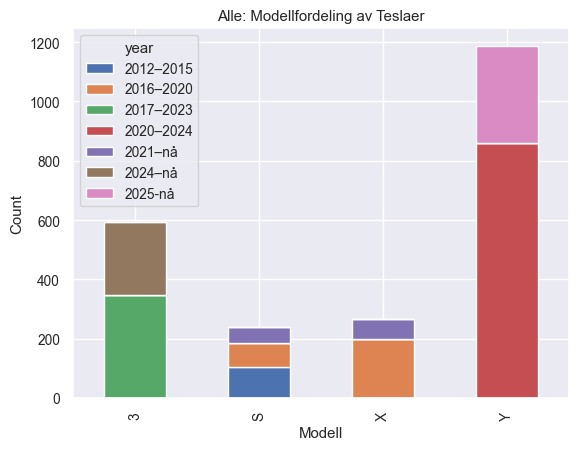

In [25]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    data = df[df['model'] != 'other']
    crosstab = pd.crosstab(data['model'], data['year'])
    crosstab.plot(kind='bar', stacked=True)

    plt.title(f'{annotation_name}: Modellfordeling av Teslaer')
    plt.xlabel('Modell')
    plt.ylabel('Count')
    plt.show()

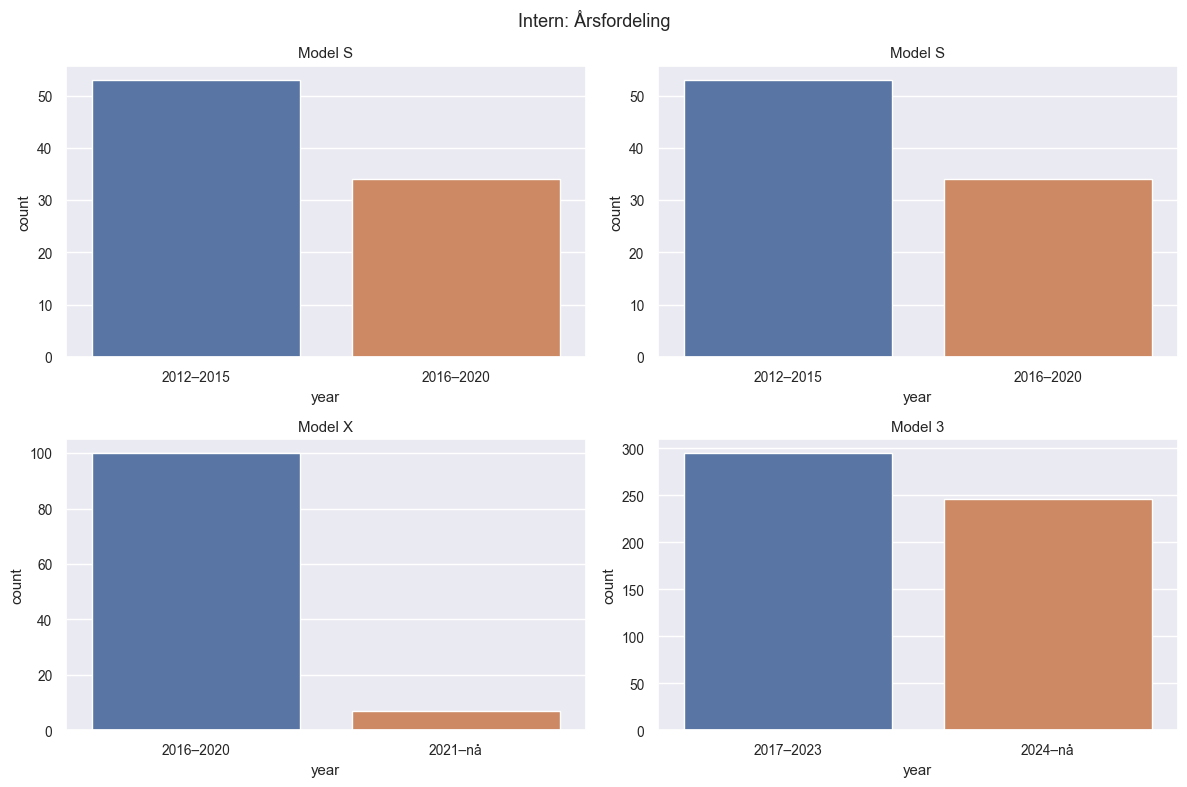

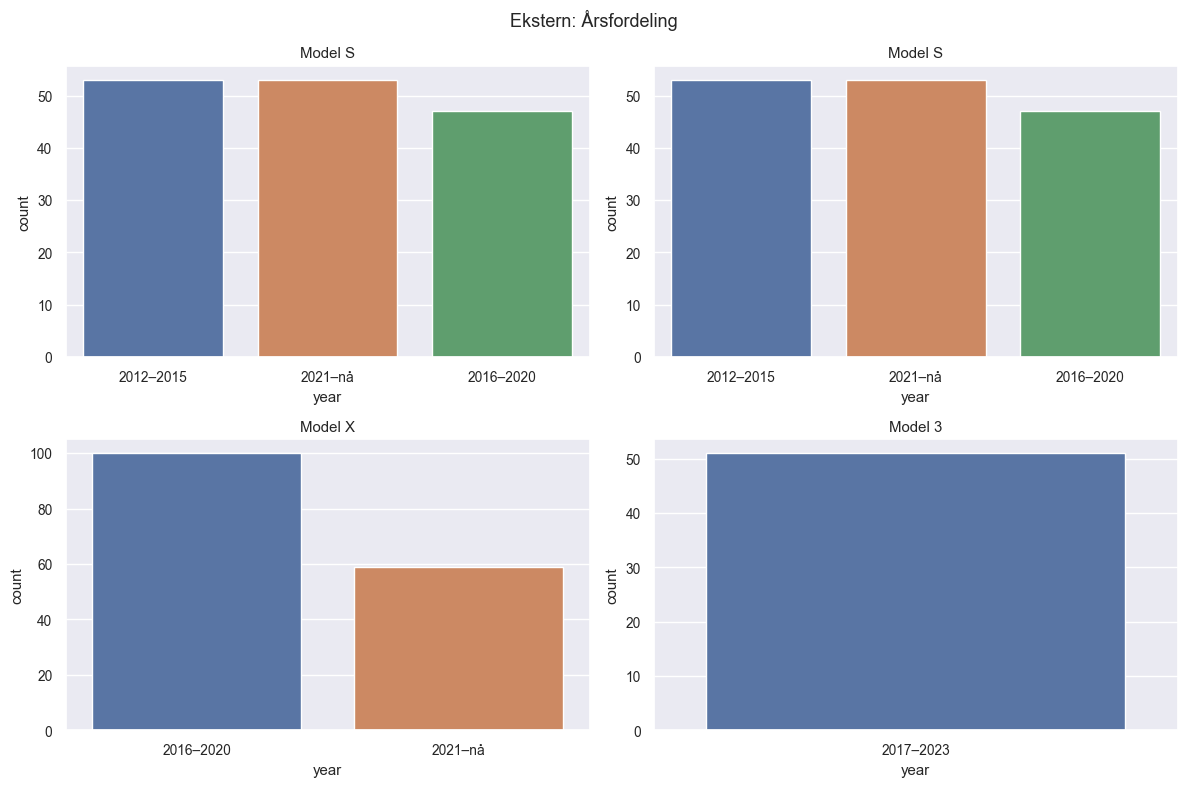

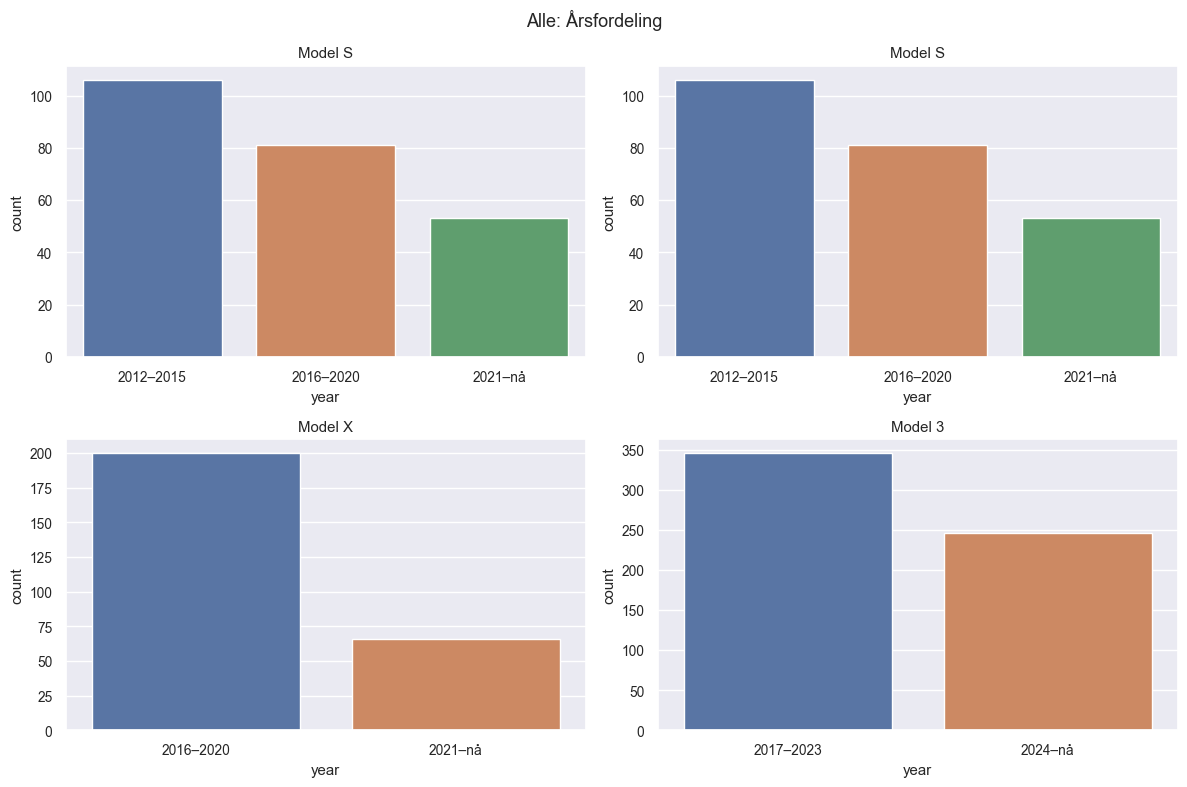

In [26]:
for annotation_name, annotation in annotations.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Årsfordeling')
    for i in range(0,2):
        for j in range(0,2):
            sns.countplot(x='year', data=list(annotation["filtered"].values())[i+j*i], ax=axes[i,j], hue='year')
            axes[i,j].title.set_text(list(annotation["filtered"].keys())[i+j*i])

    plt.tight_layout()
    plt.show()

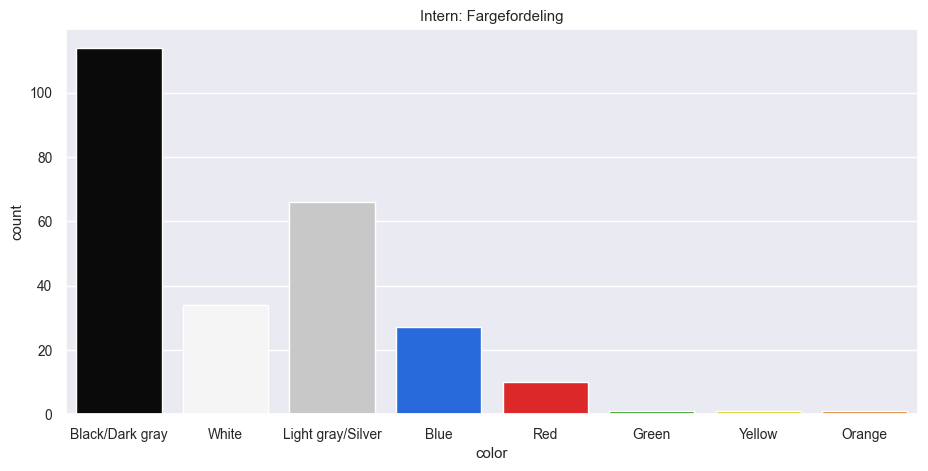

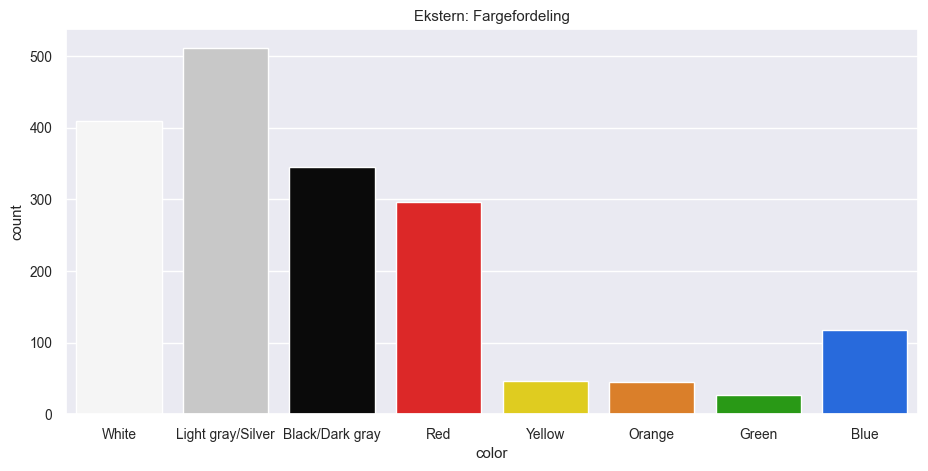

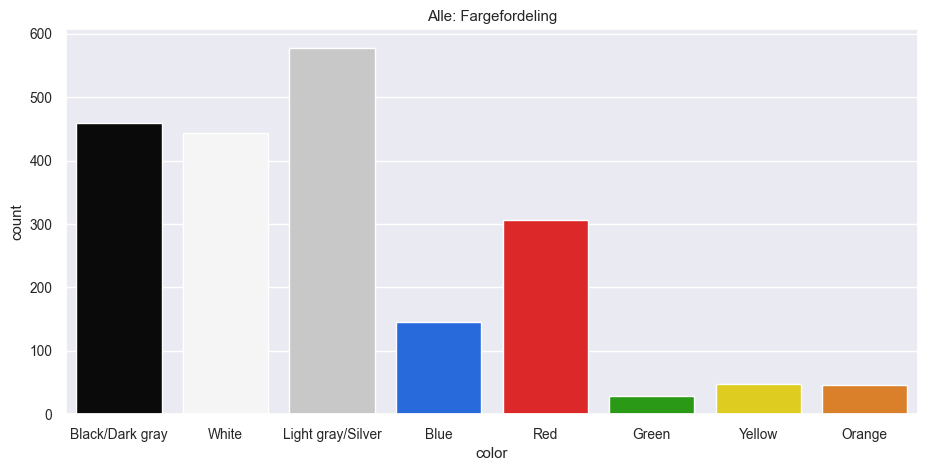

In [27]:
for annotation_name, annotation in annotations.items():
    f = plt.figure()
    f.set_figwidth(11)
    f.set_figheight(5)
    df = annotation["cars"]
    data = df[df['model'] == other]
    fig = sns.countplot(data=data, x='color', hue='color', palette=get_palette(data["color"].unique()))
    fig.set_title(f'{annotation_name}: Fargefordeling')
    plt.show()


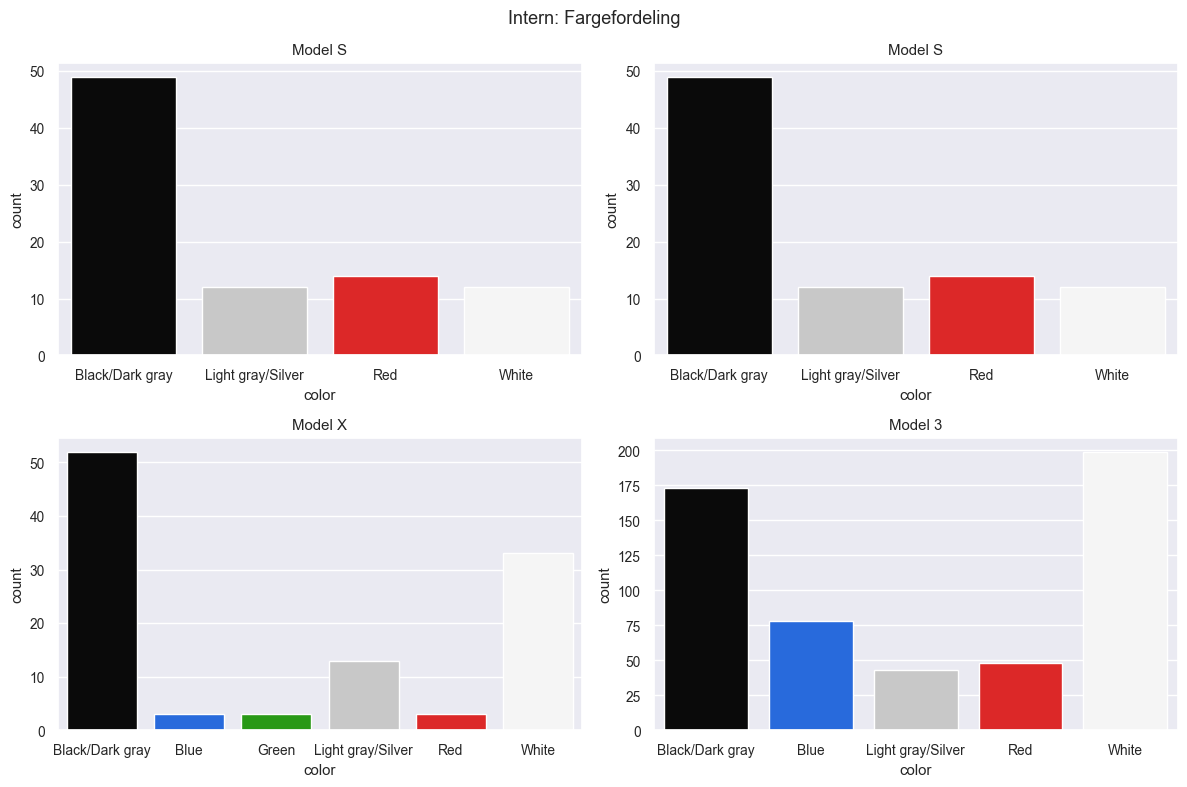

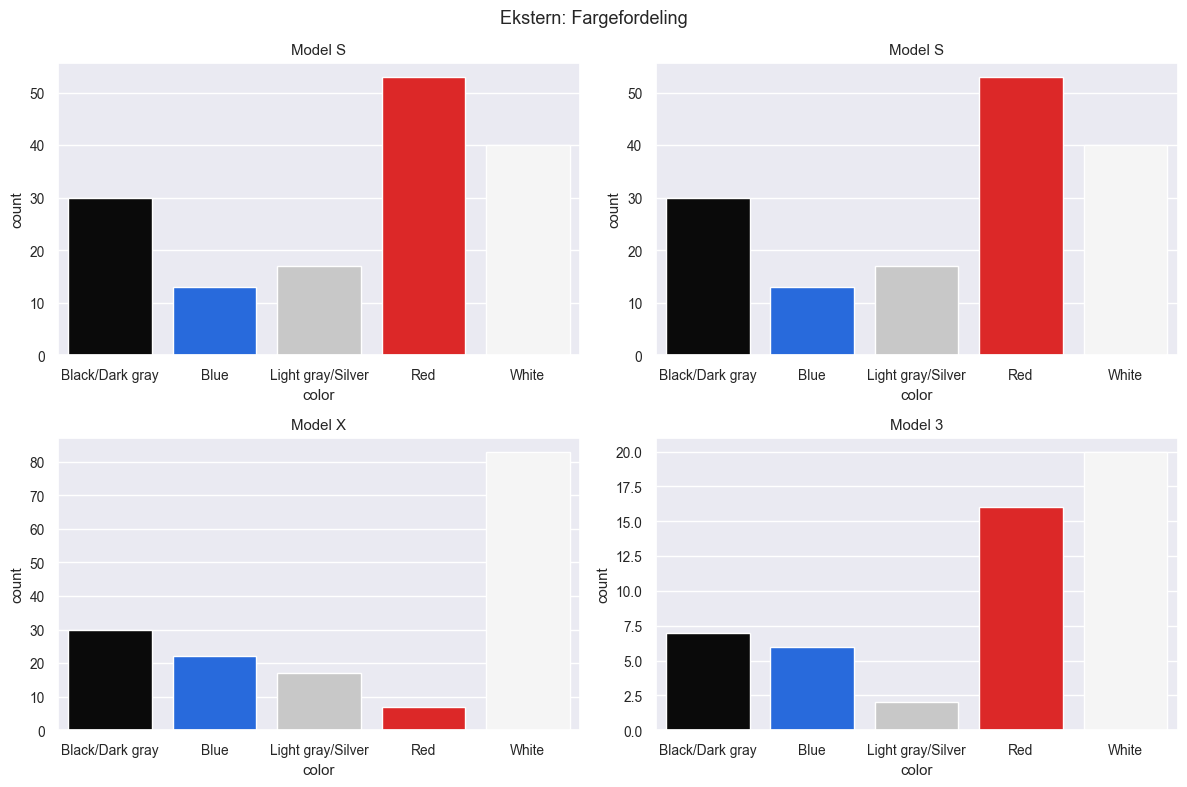

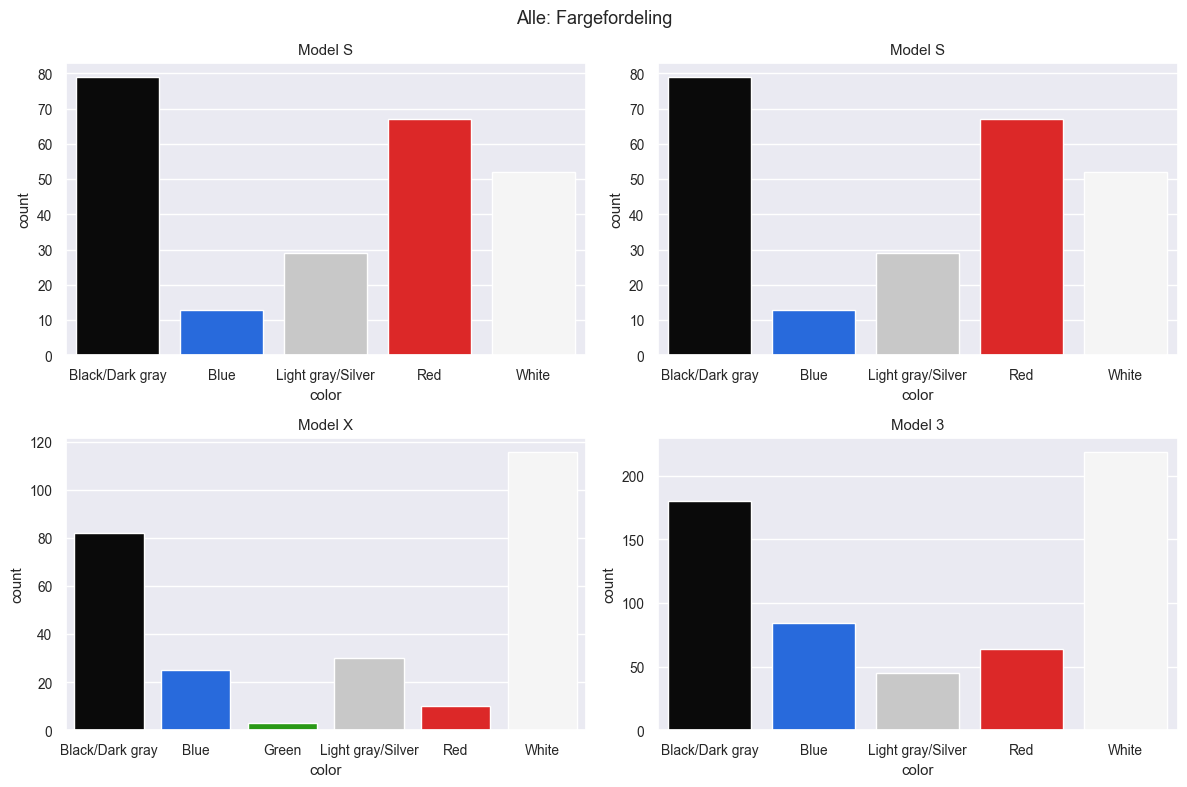

In [28]:
for annotation_name, annotation in annotations.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Fargefordeling')
    for i in range(0,2):
        for j in range(0,2):
            data = list(annotation["filtered"].values())[i+j*i].sort_values(by="color")
            sns.countplot(x='color', data=data, ax=axes[i,j], hue="color", palette=get_palette(data["color"].unique()))
            axes[i,j].title.set_text(list(annotation["filtered"].keys())[i+j*i])

    plt.tight_layout()
    plt.show()

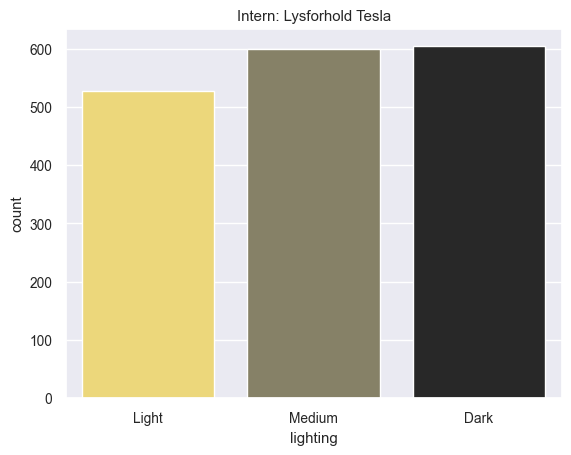

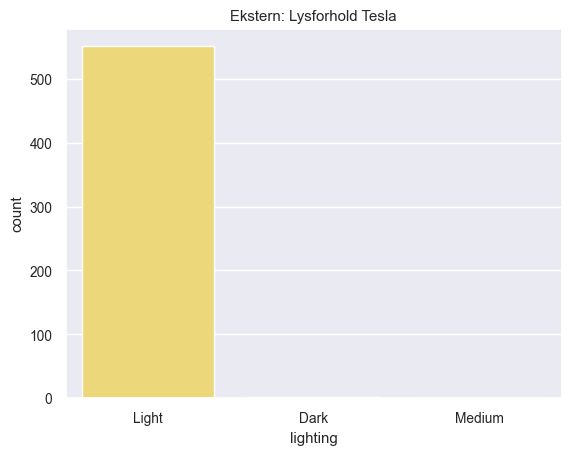

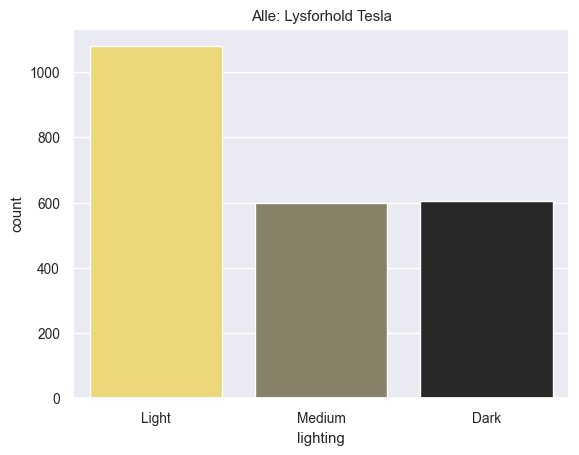

In [29]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    plot = sns.countplot(data=df[df['model'] != other], x='lighting', hue='lighting', palette=lighting_palette)
    plot.set_title(f'{annotation_name}: Lysforhold Tesla')
    plt.show()

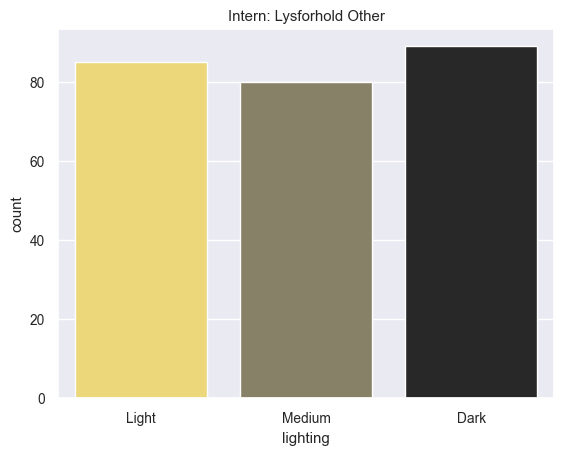

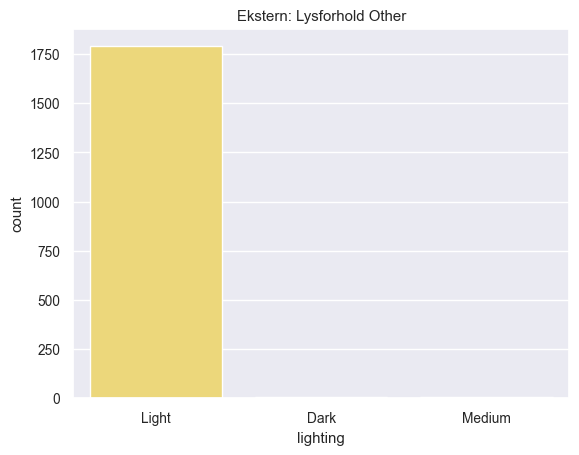

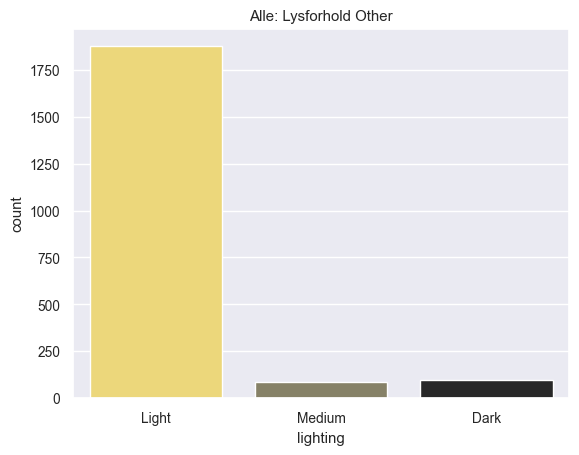

In [30]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    plot = sns.countplot(data=df[df['model'] == other], x='lighting', hue='lighting', palette=lighting_palette)
    plot.set_title(f'{annotation_name}: Lysforhold Other')
    plt.show()

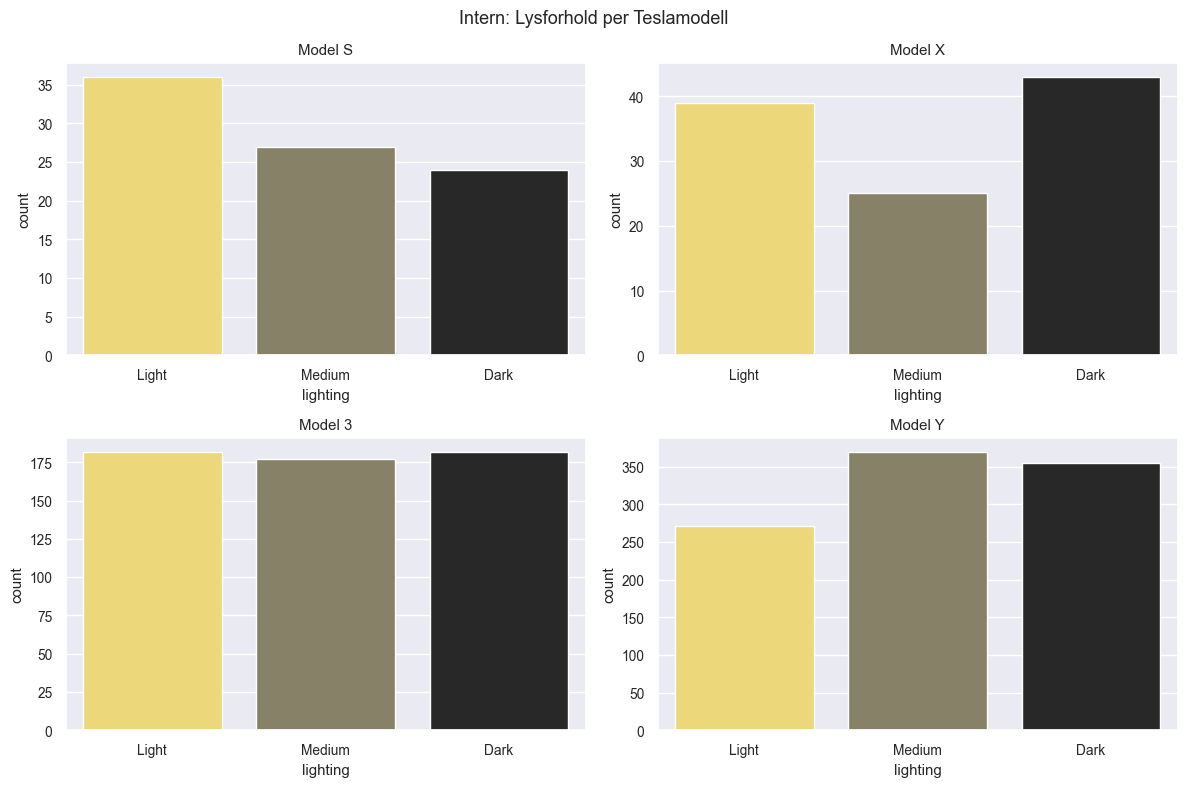

C:\Users\johan\AppData\Local\Temp\ipykernel_26568\565526195.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(x='lighting', data=list(annotation["filtered"].values())[0], ax=axes[0,0], hue='lighting', palette=lighting_palette)
C:\Users\johan\AppData\Local\Temp\ipykernel_26568\565526195.py:6: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.countplot(x='lighting', data=list(annotation["filtered"].values())[1], ax=axes[0,1], hue='lighting', palette=lighting_palette)
C:\Users\johan\AppData\Local\Temp\ipykernel_26568\565526195.py:7: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.countplot(x='lighting', data=list(annotation["filtered"].values())[2], ax=axes[1,0], hue='lighting', palette=lighting_palette)
C:\Users\johan\AppData\Local\Temp\ipykernel_26568\565526195.py:8: UserWarning: The palette list has more values (3) than 

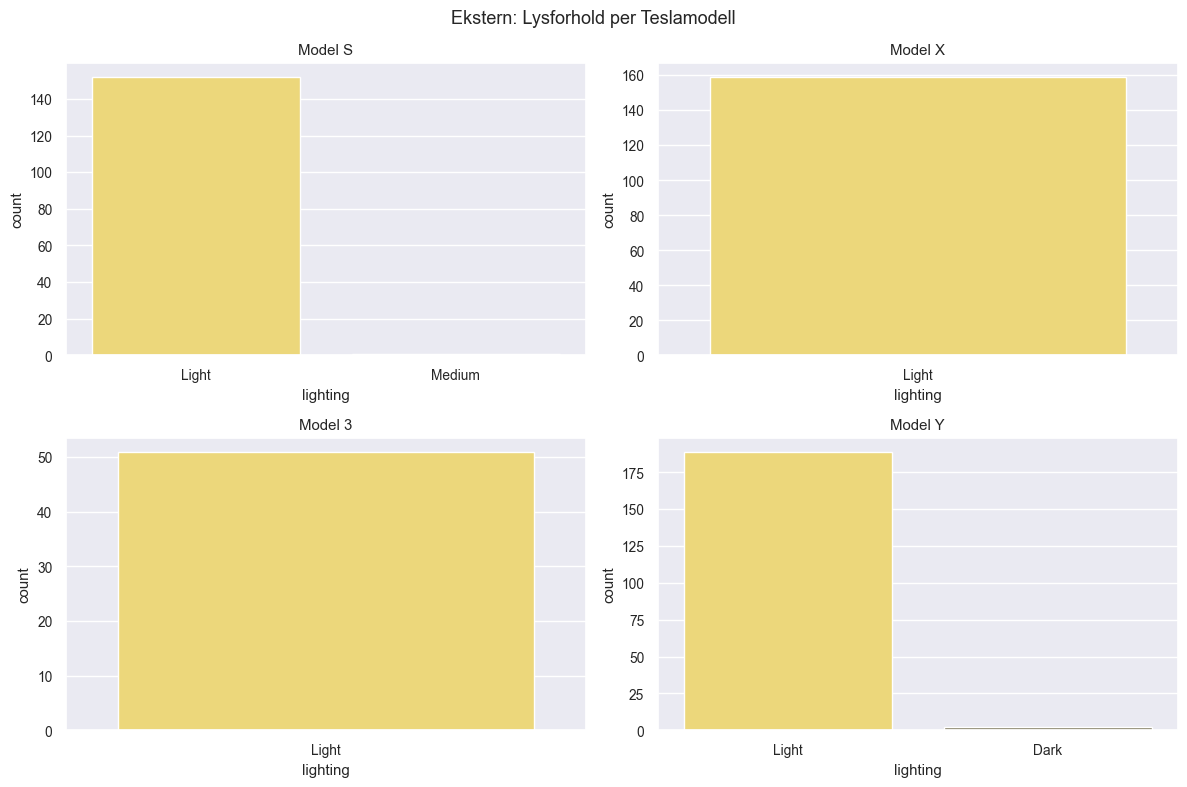

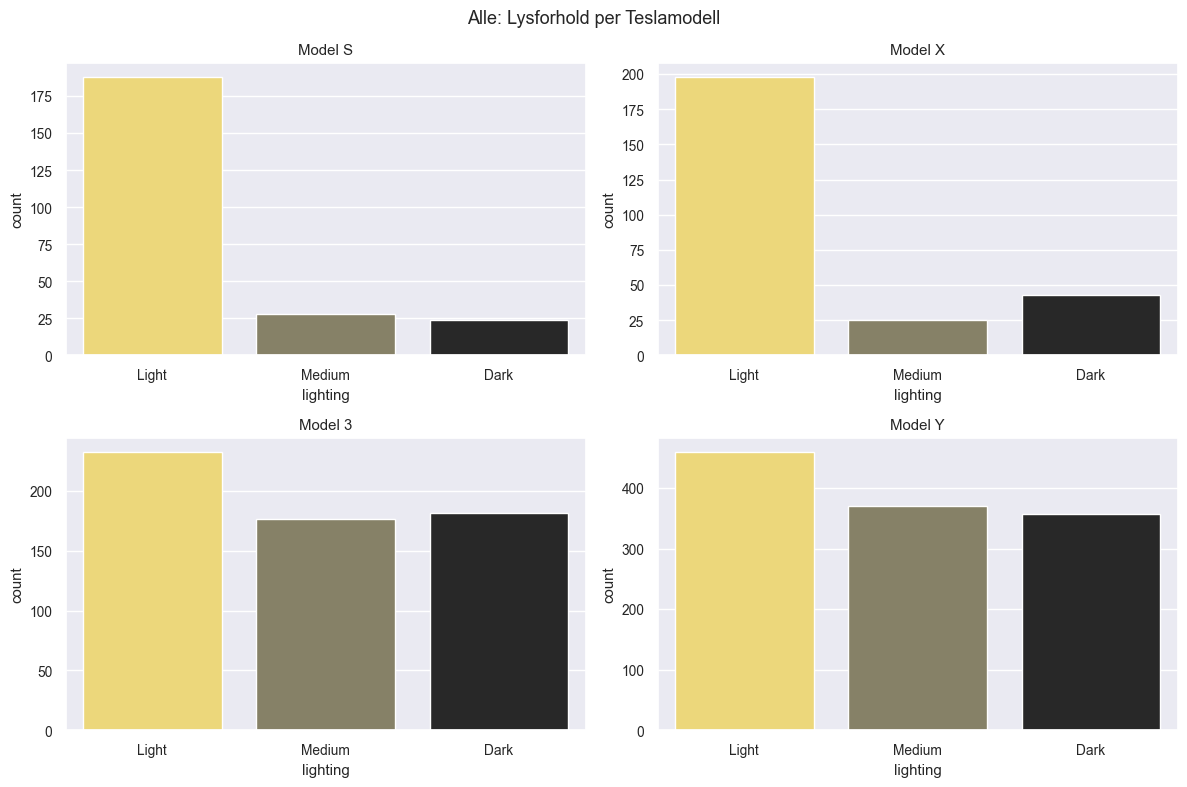

In [31]:
for annotation_name, annotation in annotations.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Lysforhold per Teslamodell')

    sns.countplot(x='lighting', data=list(annotation["filtered"].values())[0], ax=axes[0,0], hue='lighting', palette=lighting_palette)
    sns.countplot(x='lighting', data=list(annotation["filtered"].values())[1], ax=axes[0,1], hue='lighting', palette=lighting_palette)
    sns.countplot(x='lighting', data=list(annotation["filtered"].values())[2], ax=axes[1,0], hue='lighting', palette=lighting_palette)
    sns.countplot(x='lighting', data=list(annotation["filtered"].values())[3], ax=axes[1,1], hue='lighting', palette=lighting_palette)
    axes[0,0].title.set_text(list(annotation["filtered"].keys())[0])
    axes[0,1].title.set_text(list(annotation["filtered"].keys())[1])
    axes[1,0].title.set_text(list(annotation["filtered"].keys())[2])
    axes[1,1].title.set_text(list(annotation["filtered"].keys())[3])

    plt.tight_layout()
    plt.show()